# SHAP Dependence

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ing-bank/probatus/blob/master/docs/getting-started/shap_dependence_plotter.ipynb)

This notebook demonstrates the use of the `model.shap_dependence_plotter` module, which helps explain models using SHAP values.

### Imports

First, let's import the necessary dependencies and configure the settings.

In [4]:
%%capture
!pip install probatus

In [5]:
import warnings
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from probatus.model import DependencePlotter

# Suppress warnings for a cleaner output.
warnings.filterwarnings("ignore")

### Data preparation
Now, let's load a sample dataset

In [6]:
# Download and read the dataset
iris = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv")

# Change the problem in a binary classification problem: 'setosa' or not.
iris["species"] = iris["species"].apply(lambda x: 1 if x == "setosa" else 0)
iris = iris.rename(columns={"species": "setosa"})

# Extract the relevant features
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
X = iris[features]
y = iris["setosa"]

# Show the dataset
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,setosa
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


and let's train a random forest classifier:

In [7]:
model = RandomForestClassifier()
model = model.fit(X, y)

### Shap dependence
First, we fit the `DependencePlotter`

In [8]:
class_names = ["Not setosa", "Setosa"]
tdp = DependencePlotter(model).fit(X, y, class_names=class_names)

Now, we can visualize the SHAP dependence for a specific feature. The top plot displays the SHAP values for the selected feature, while the bottom plot shows the distribution of feature values along with the corresponding target rate.

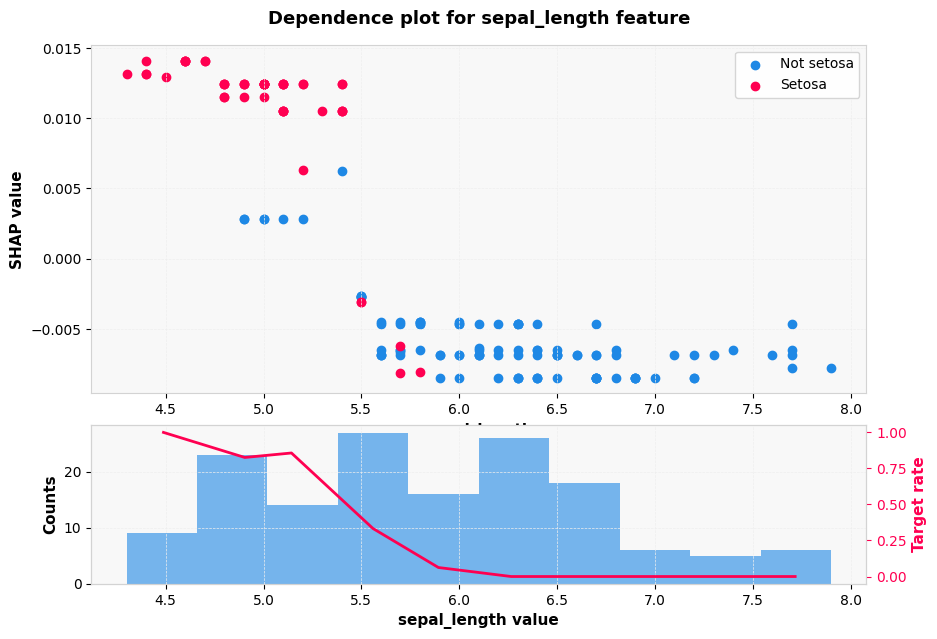

In [9]:
fig = tdp.plot(feature="sepal_length", figsize=(10, 7))

- **Top Plot**: The scatter plot illustrates SHAP values for the `sepal_length` feature. Each point represents an individual data sample, with colors indicating class labels.  
  - Orange correspond to the positive class (`Setosa`).  
  - Blue points correspond to the negative class (`Not Setosa`).  
  - The trend shows that lower `sepal_length` values contribute positively to the model's decision for `Setosa`, while higher values have a negative contribution.  

- **Bottom Plot**:  
  - The histogram represents the distribution of `sepal_length` values across the dataset.  
  - The red line indicates the target rate, showing how likely a sample belongs to the positive class (`Setosa`) at different feature values.  
  - As `sepal_length` increases, the probability of belonging to the positive class (`Setosa`) decreases.  

This visualization helps in understanding how `sepal_length` influences the model's predictions.

### Plotting with Outliers  

In this section, we artificially introduce an outlier into the dataset to observe its impact on the SHAP dependence plot. While the presence of outliers distorts the visualization, we can adjust the plotter's parameters to mitigate this issue.

#### Adding an Outlier  

We modify the dataset by setting an extreme value for the `sepal_length` feature:  

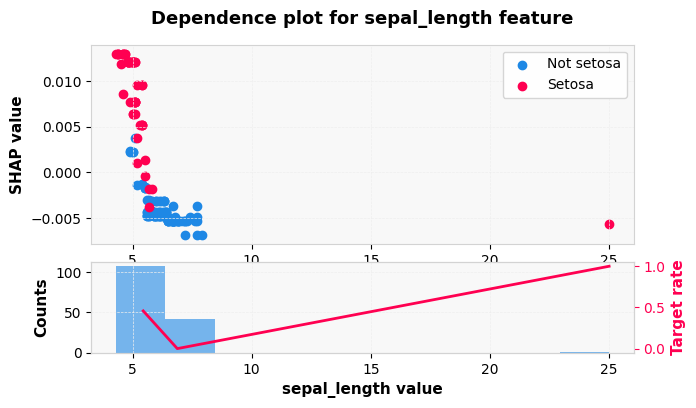

In [10]:
# Add an outlier
X.at[0, "sepal_length"] = 25

# Retrain the classifier and fit the plotter
model = RandomForestClassifier().fit(X, y)
tdp = DependencePlotter(model).fit(X, y, class_names=class_names)

# Plot the dependence plot.
fig = tdp.plot(feature="sepal_length", figsize=(7, 4))

#### Observations  

- The presence of an extreme outlier at `sepal_length = 25` distorts the plot, making it difficult to interpret.  
- The SHAP values for most data points remain clustered around their original distribution, while the outlier introduces an unnatural spread.  
- The histogram at the bottom becomes misleading, as most values are concentrated within a normal range, while the outlier skews the scale.  

### Removing the Outliers  

To correct this, we can filter out extreme values by using the `min_q` and `max_q` parameters:  

- `min_q` specifies the minimum quantile threshold, excluding extreme lower values.  
- `max_q` sets the maximum quantile threshold, removing extreme upper values.  

In this case, since there is only one large outlier, setting `max_q = 0.99` effectively removes it:  

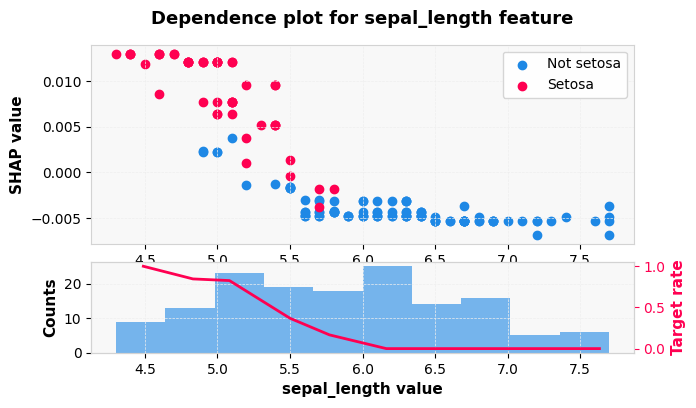

In [11]:
fig = tdp.plot(feature="sepal_length", figsize=(7, 4), max_q=0.99)


By applying this adjustment, we restore readability to the plot and improve the interpretability of the SHAP dependence visualization.